# Random Forest — Sample Day: Actual vs. Prediction

Loads validation-set predictions for all three RF feature sets and plots a single day.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

In [2]:
RESULTS_DIR = Path("../../results/02_random_forest")

models = {
    "RF Base": RESULTS_DIR / "random_forest_base_predictions_val.csv",
    "RF + Time": RESULTS_DIR / "random_forest_base_with_time_predictions_val.csv",
    "RF + Time + Lag": RESULTS_DIR / "random_forest_base_with_time_and_lag_predictions_val.csv",
}

dfs = {}
for name, path in models.items():
    df = pd.read_csv(path, parse_dates=["timestamp"])
    df = df.set_index("timestamp")
    dfs[name] = df

# All share the same y_true — use any one
ref = next(iter(dfs.values()))
available_dates = ref.index.normalize().unique()
print(f"Val set: {available_dates[0].date()} → {available_dates[-1].date()}  ({len(available_dates)} days)")

Val set: 2024-06-14 → 2024-12-15  (185 days)


In [3]:
# Pick a sample day — change this to any date in the val set
SAMPLE_DAY = "2024-07-15"

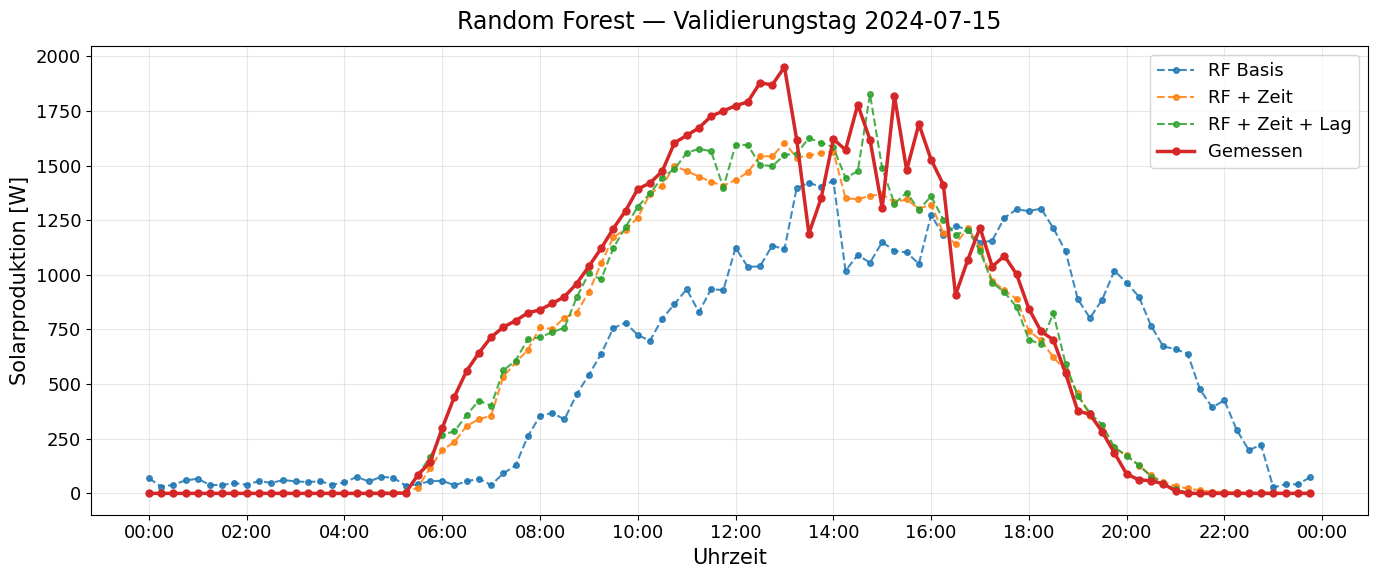

In [4]:
plt.style.use("default")
plt.rcParams.update({"font.size": 14})

fig, ax = plt.subplots(figsize=(14, 6))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
model_labels = {
    "RF Base": "RF Basis",
    "RF + Time": "RF + Zeit",
    "RF + Time + Lag": "RF + Zeit + Lag",
}

for (name, df), color in zip(dfs.items(), colors):
    day = df.loc[SAMPLE_DAY, "y_pred"]
    ax.plot(day.index, day.values, linewidth=1.5, linestyle="--", color=color,
            marker="o", markersize=4, label=model_labels[name], alpha=0.85)

actual = ref.loc[SAMPLE_DAY, "y_true"]
ax.plot(actual.index, actual.values,
        color="#d62728", linewidth=2.5, marker="o", markersize=5,
        label="Gemessen", zorder=10)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.tick_params(labelsize=13)
ax.set_xlabel("Uhrzeit", fontsize=15)
ax.set_ylabel("Solarproduktion [W]", fontsize=15)
ax.set_title(f"Random Forest — Validierungstag {SAMPLE_DAY}", fontsize=17, pad=12)
ax.legend(fontsize=13)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [5]:
print(f"MAE am {SAMPLE_DAY}:")
for name, df in dfs.items():
    day = df.loc[SAMPLE_DAY]
    mae = (day["y_pred"] - day["y_true"]).abs().mean()
    label = model_labels[name]
    print(f"  {label:<22} {mae:,.0f} W")

MAE am 2024-07-15:
  RF Basis               379 W
  RF + Zeit              107 W
  RF + Zeit + Lag        97 W
